# Simulating and exploring synthetic data

In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
from utils.data import read_data_files

## Triplets found in Binary data

In [2]:
import ast
from metrics.synergy import *

directory = "data/datasets/binary_data"
csv_by_id, metadata_by_id, = read_data_files(directory)

In [3]:
import pickle
from pathlib import Path
idx = 302

folder = "binary_data"
with open(f"data/triplets/{Path(folder).name}.pkl", "rb") as f:
    triplet_data = pickle.load(f)

dict_idx = triplet_data[idx]    
print(dict_idx)

{'Ratio': 1.0, 'Total': 4, 'Found': 4, 'N_Vars': 20, 'Metric': 'InteractionInformation', 'Directory': 'binary_data', 'File': 302, 'Triplets': [('5', '13', '19'), ('0', '9', '14'), ('1', '2', '7'), ('13', '14', '16'), ('1', '2', '18')]}


In [4]:
csv_by_id[idx].attrs

{'i': 302,
 'total_vars': 20,
 'dag_family': 'ba',
 'p_syn': 0.5,
 'p_noise': 0.0,
 'samples': 2000}

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

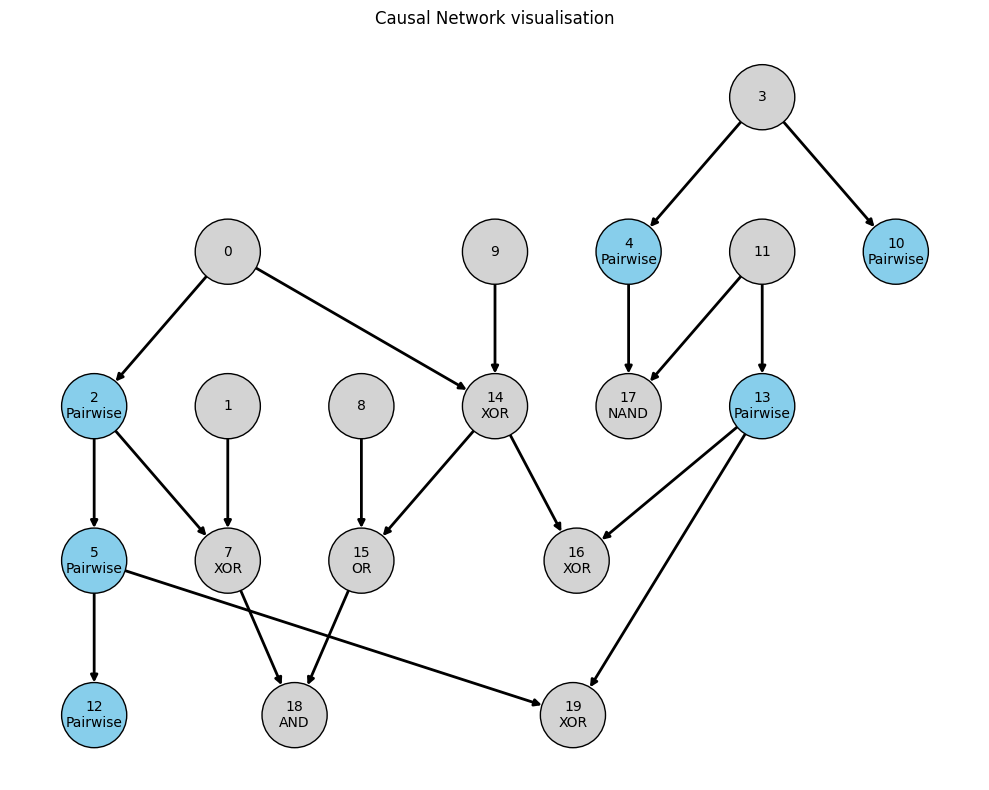

In [5]:
from utils.plotting import *
metadata = metadata_by_id[idx]
visualize_network_labels(metadata)

In [6]:
from idtxl.estimators_pid import TartuPID

def broja_synergy(df, source1, source2, target):
    s1, _ = pd.factorize(df[source1], sort=True)
    s2, _ = pd.factorize(df[source2], sort=True)
    t,  _ = pd.factorize(df[target], sort=True)

    data = Data(np.vstack((s1, s2, t)), 'ps', normalise=False)

    settings = {
        'alpha': 0.1,
        'alph_s1': int(s1.max() + 1),
        'alph_s2': int(s2.max() + 1),
        'alph_t': int(t.max() + 1),
        'max_unsuc_swaps_row_parm': 60,
        'num_reps': 63,
        'max_iters': 1000,
        'pid_estimator': 'TartuPID',
        'verbose': False,
        'lags_pid': [0, 0],   # or remove if you do not want lagged PID
    }

    pid_analysis = BivariatePID()
    results = pid_analysis.analyse_single_target(
        settings=settings,
        data=data,
        target=2,
        sources=[0, 1],
    )
    return results.get_single_target(2)['syn_s1_s2']

In [7]:
for triplet in triplet_data[idx]["Triplets"]:
    print(triplet)
    pid = broja_synergy(csv_by_id[idx], triplet[0], triplet[1], triplet[2])
    print(pid)

('5', '13', '19')
0.9946106859334894
('0', '9', '14')
0.9894804381731672
('1', '2', '7')
0.9841577228745325
('13', '14', '16')
0.9716015022697375
('1', '2', '18')
0.5330108621993483


In [8]:

metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "XOR", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

pair_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] != "XOR", "Combs"]
]
pair_triplets = [triplet for triplet in pair_triplets if len(triplet) > 2]
csv_by_id[idx].attrs

{'i': 302,
 'total_vars': 20,
 'dag_family': 'ba',
 'p_syn': 0.5,
 'p_noise': 0.0,
 'samples': 2000}

In [9]:
from typing import Sequence
import numpy as np
import pandas as pd

from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.stats import syn_shd_against_surrogates


def classify_collider_by_pid_significance(
    df: pd.DataFrame,
    triplet: Sequence[str | int],
    *,
    alph_s1: int | None = None,
    alph_s2: int | None = None,
    alph_t: int | None = None,
    alpha: float = 0.05,
    n_perm: int = 1_000,
):
    """
    Classify a fixed collider candidate (source1, source2 -> target)
    without a manually chosen effect-size threshold.

    Decision rule:
        synergistic <=> syn_s1_s2 is significant under surrogate testing
    """
    if len(triplet) != 3:
        raise ValueError(f"triplet must have length 3, got {len(triplet)}")

    source1, source2, target = triplet

    if not all(isinstance(x, str) for x in (source1, source2, target)):
        source1, source2, target = map(str, triplet)

    x = df[source1].to_numpy()
    y = df[source2].to_numpy()
    z = df[target].to_numpy()

    if alph_s1 is None:
        alph_s1 = int(df[source1].nunique())
    if alph_s2 is None:
        alph_s2 = int(df[source2].nunique())
    if alph_t is None:
        alph_t = int(df[target].nunique())

    data = Data(np.vstack((x, y, z)), "ps", normalise=False)

    settings = {
        "pid_estimator": "TartuPID",
        "alph_s1": alph_s1,
        "alph_s2": alph_s2,
        "alph_t": alph_t,
        # "max_unsuc_swaps_row_parm": 60,
        # "num_reps": 100,
        # "max_iters": 100_000,
        "verbose": False,
        "lags_pid": [0, 0],
        "alpha": alpha,
        "n_perm": n_perm,
        "permute_in_time": True,
    }

    pid = BivariatePID()
    pid._initialise(settings, data, target=2, sources=[0, 1])

    orig_pid, shd_sig, shd_p, syn_sig, syn_p = syn_shd_against_surrogates(pid, data)

    syn = float(orig_pid["syn_s1_s2"])
    shd = float(orig_pid["shd_s1_s2"])
    unq_s1 = float(orig_pid["unq_s1"])
    unq_s2 = float(orig_pid["unq_s2"])

    total_info = syn + shd + unq_s1 + unq_s2
    synergy_fraction = syn / total_info if total_info > 0 else 0.0

    label = "synergistic" if syn_sig and syn > 0 else "not_synergistic"

    return {
        "triplet": (source1, source2, target),
        "label": label,
        "syn_s1_s2": syn,
        "shd_s1_s2": shd,
        "unq_s1": unq_s1,
        "unq_s2": unq_s2,
        "total_info": total_info,
        "synergy_fraction": synergy_fraction,
        "syn_sig": bool(syn_sig),
        "syn_p": float(syn_p),
        "shd_sig": bool(shd_sig),
        "shd_p": float(shd_p),
    }

In [10]:
print("Evaluating triplets with PID-based classification: SRVs")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in srv_triplets
)
for i in sorted_triplets:
    print(i)

print("Evaluating triplets with PID-based classification: Pairwise")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in pair_triplets
)

for i in sorted_triplets:
    print(i)


Evaluating triplets with PID-based classification: SRVs
{'triplet': ('1', '2', '7'), 'label': 'synergistic', 'syn_s1_s2': 0.9841577228745325, 'shd_s1_s2': 5.659419597460063e-05, 'unq_s1': 0.00010418375083501622, 'unq_s2': -3.6924615334500565e-11, 'total_info': 0.9843185007844175, 'synergy_fraction': 0.9998366606847714, 'syn_sig': True, 'syn_p': 0.001, 'shd_sig': False, 'shd_p': 0.488}
{'triplet': ('0', '9', '14'), 'label': 'synergistic', 'syn_s1_s2': 0.9894804381731672, 'shd_s1_s2': 2.9586467309739463e-06, 'unq_s1': 0.0001009899735560588, 'unq_s2': -1.17042905542092e-09, 'total_info': 0.9895843856230251, 'synergy_fraction': 0.999894958478157, 'syn_sig': True, 'syn_p': 0.001, 'shd_sig': False, 'shd_p': 0.829}
{'triplet': ('13', '14', '16'), 'label': 'synergistic', 'syn_s1_s2': 0.9716015022697375, 'shd_s1_s2': 9.54729599339838e-06, 'unq_s1': -8.905145377953995e-10, 'unq_s2': 0.000130889919970051, 'total_info': 0.9717419385951864, 'synergy_fraction': 0.9998554798142685, 'syn_sig': True, '

In [11]:
csv_by_id[idx].columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'],
      dtype='object')

## Triplets found in JPMF data

In [12]:
import ast
from metrics.synergy import *

directory = "data/datasets/jpmf_final"
csv_by_id, metadata_by_id, = read_data_files(directory)

In [13]:
import pickle
from pathlib import Path
idx = 545

folder = "jpmf_data"
with open(f"data/triplets/{Path(folder).name}.pkl", "rb") as f:
    triplet_data = pickle.load(f)

dict_idx = triplet_data[idx]    
print(dict_idx)

{'Ratio': 0.6666666666666666, 'Total': 3, 'Found': 2, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 545, 'Triplets': [('4', '8', '9'), ('0', '1', '4')]}


In [14]:
csv_by_id[idx].attrs

{'i': 545,
 'family': 'small-world',
 'target_mi': 0.4754887502163468,
 'pair_probs': 0.5,
 'syn_cutoff': 0.7,
 'num_vars': 10}

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

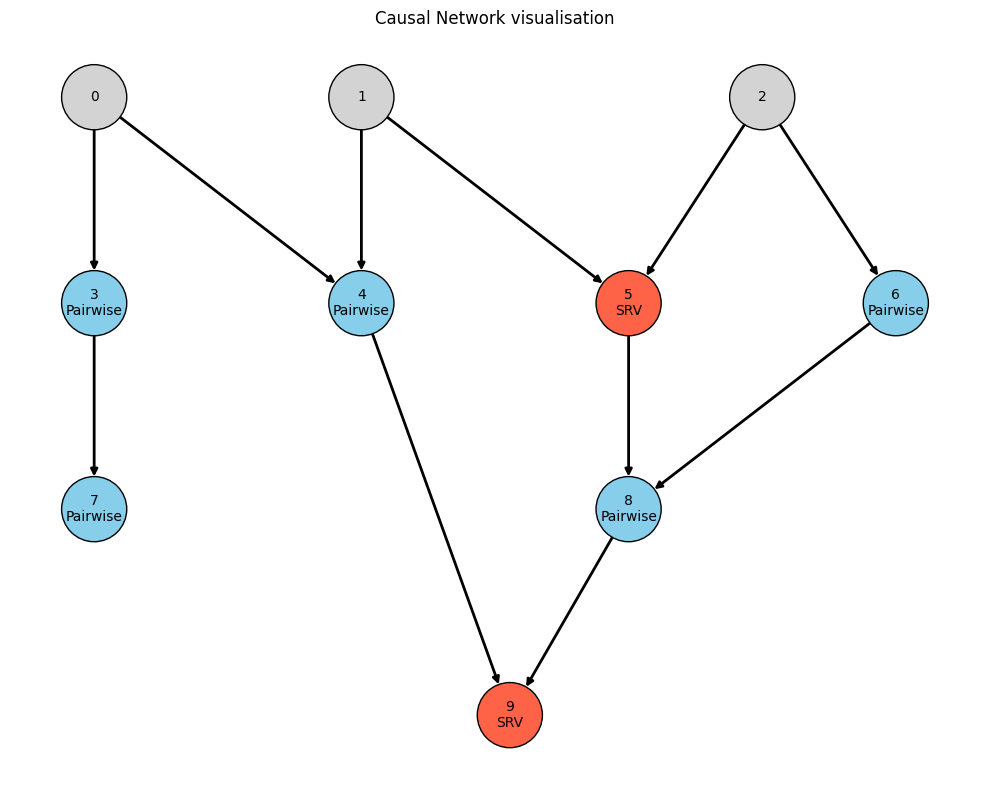

In [15]:
from utils.plotting import *
metadata = metadata_by_id[idx]
visualize_network_labels(metadata)

In [16]:

metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "SRV", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

pair_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] != "SRV", "Combs"]
]
pair_triplets = [triplet for triplet in pair_triplets if len(triplet) > 2]
csv_by_id[idx].attrs

{'i': 545,
 'family': 'small-world',
 'target_mi': 0.4754887502163468,
 'pair_probs': 0.5,
 'syn_cutoff': 0.7,
 'num_vars': 10}

In [34]:
from typing import Sequence
import numpy as np
import pandas as pd

from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.stats import syn_shd_against_surrogates


def classify_collider_by_pid_significance(
    df: pd.DataFrame,
    triplet: Sequence[str | int],
    *,
    alph_s1: int | None = None,
    alph_s2: int | None = None,
    alph_t: int | None = None,
    alpha: float = 0.05,
    n_perm: int = 1_000,
):
    """
    Classify a fixed collider candidate (source1, source2 -> target)
    without a manually chosen effect-size threshold.

    Decision rule:
        synergistic <=> syn_s1_s2 is significant under surrogate testing
    """
    if len(triplet) != 3:
        raise ValueError(f"triplet must have length 3, got {len(triplet)}")

    source1, source2, target = triplet

    if not all(isinstance(x, str) for x in (source1, source2, target)):
        source1, source2, target = map(str, triplet)

    x = df[source1].to_numpy()
    y = df[source2].to_numpy()
    z = df[target].to_numpy()

    if alph_s1 is None:
        alph_s1 = int(df[source1].nunique())
    if alph_s2 is None:
        alph_s2 = int(df[source2].nunique())
    if alph_t is None:
        alph_t = int(df[target].nunique())

    data = Data(np.vstack((x, y, z)), "ps", normalise=False)

    settings = {
        "pid_estimator": "TartuPID",
        "alph_s1": alph_s1,
        "alph_s2": alph_s2,
        "alph_t": alph_t,
        # "max_unsuc_swaps_row_parm": 60,
        # "num_reps": 100,
        # "max_iters": 100_000,
        "verbose": False,
        "lags_pid": [0, 0],
        "alpha": alpha,
        "n_perm": n_perm,
        "permute_in_time": True,
    }

    pid = BivariatePID()
    pid._initialise(settings, data, target=1, sources=[0, 2])
    
    pid = pid.analyse_single_target(
        settings=settings,
        data=data,
        target=2,
        sources=[0, 1],
    ).get_single_target(2)
 
    syn = float(pid["syn_s1_s2"])
    shd = float(pid["shd_s1_s2"])
    unq_s1 = float(pid["unq_s1"])
    unq_s2 = float(pid["unq_s2"])

    total_info = syn + shd + unq_s1 + unq_s2
    synergy_fraction = syn / total_info if total_info > 0 else 0.0

    label = "synergistic" if synergy_fraction > 0.5 else "pairwise"

    return {
        "triplet": (source1, source2, target),
        "label": label,
        "syn_s1_s2": syn,
        "shd_s1_s2": shd,
        "unq_s1": unq_s1,
        "unq_s2": unq_s2,
        "total_info": total_info,
        "synergy_fraction": synergy_fraction,
    }

In [35]:
print("Evaluating triplets with PID-based classification: SRVs")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in srv_triplets
)
for i in sorted_triplets:
    print(i)

print("Evaluating triplets with PID-based classification: Pairwise")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in pair_triplets
)

for i in sorted_triplets:
    print(i)


Evaluating triplets with PID-based classification: SRVs
{'triplet': ('1', '2', '5'), 'label': 'synergistic', 'syn_s1_s2': 0.5395113844283921, 'shd_s1_s2': 0.17196825759472034, 'unq_s1': 0.009611833532056, 'unq_s2': 0.07395265524208713, 'total_info': 0.7950441307972556, 'synergy_fraction': 0.6785930032429521}
{'triplet': ('4', '8', '9'), 'label': 'synergistic', 'syn_s1_s2': 1.0778979314972799, 'shd_s1_s2': 0.004524520434152805, 'unq_s1': 0.09589322974032935, 'unq_s2': -2.306895544832283e-10, 'total_info': 1.1783156814410727, 'synergy_fraction': 0.9147785678104677}
Evaluating triplets with PID-based classification: Pairwise
{'triplet': ('0', '1', '4'), 'label': 'pairwise', 'syn_s1_s2': 0.18294165963476328, 'shd_s1_s2': 0.0734106347617934, 'unq_s1': 0.2368467534349468, 'unq_s2': 0.021731186944073624, 'total_info': 0.5149302347755771, 'synergy_fraction': 0.3552746513602858}
{'triplet': ('5', '6', '8'), 'label': 'pairwise', 'syn_s1_s2': 0.18107920470132566, 'shd_s1_s2': 0.04392088442049467,

In [19]:
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in triplets_data
)

NameError: name 'triplets_data' is not defined

In [ ]:
sorted_triplets

[{'triplet': ('4', '6', '17'),
  'label': 'synergistic',
  'syn_s1_s2': 0.26441264362633543,
  'shd_s1_s2': 0.0007313754517605102,
  'unq_s1': 0.37724922332013516,
  'unq_s2': -2.561802574524576e-10,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': True,
  'shd_p': 0.002},
 {'triplet': ('11', '12', '19'),
  'label': 'synergistic',
  'syn_s1_s2': 0.5021987233209613,
  'shd_s1_s2': 0.00028990313881682023,
  'unq_s1': 0.19643244028936024,
  'unq_s2': 1.580274505442322e-05,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': False,
  'shd_p': 0.238},
 {'triplet': ('9', '13', '20'),
  'label': 'synergistic',
  'syn_s1_s2': 0.16635313984453504,
  'shd_s1_s2': 0.0005540816727309614,
  'unq_s1': 0.05367667248987353,
  'unq_s2': 5.642952098248771e-05,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': True,
  'shd_p': 0.038},
 {'triplet': ('0', '13', '21'),
  'label': 'synergistic',
  'syn_s1_s2': 0.41048362694401885,
  'shd_s1_s2': 7.505659793284474e-05,
  'unq_s1': 0.02338398113408087,
  'unq_s